In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/survey lung cancer.csv")
df.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    str  
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    str  
dtypes

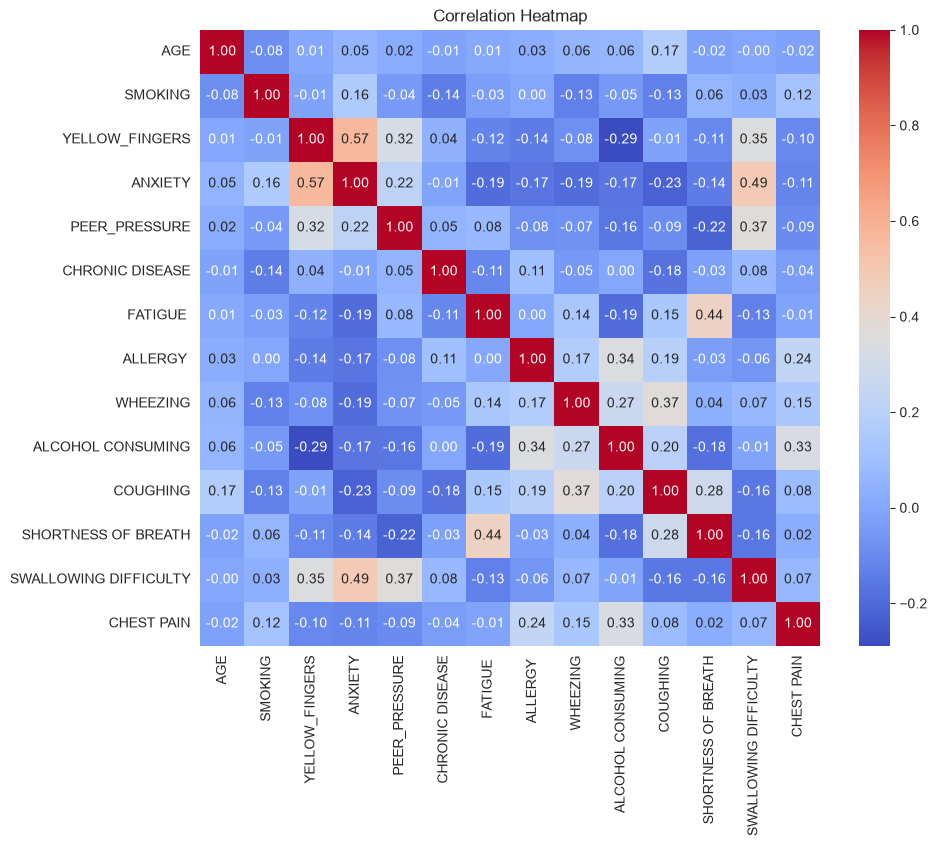

In [3]:
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['LUNG_CANCER'].value_counts())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [4]:
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "naive_bayes": GaussianNB()
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    trained_models[name] = model

    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df



--- logistic_regression ---
[[ 5  3]
 [ 3 51]]
              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.94      0.94      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.78      0.78        62
weighted avg       0.90      0.90      0.90        62


--- random_forest ---
[[ 6  2]
 [ 3 51]]
              precision    recall  f1-score   support

           0       0.67      0.75      0.71         8
           1       0.96      0.94      0.95        54

    accuracy                           0.92        62
   macro avg       0.81      0.85      0.83        62
weighted avg       0.92      0.92      0.92        62


--- naive_bayes ---
[[ 4  4]
 [ 5 49]]
              precision    recall  f1-score   support

           0       0.44      0.50      0.47         8
           1       0.92      0.91      0.92        54

    accuracy                           0.85        6

,model,accuracy,precision,recall,f1
1,random_forest,0.919355,0.962264,0.944444,0.953271
0,logistic_regression,0.903226,0.944444,0.944444,0.944444
2,naive_bayes,0.854839,0.924528,0.907407,0.915888


In [6]:
os.makedirs('../models/lung_cancer', exist_ok=True)

for name, model in trained_models.items():
    joblib.dump(model, f'../models/lung_cancer/{name}.pkl')

joblib.dump(scaler, '../models/lung_cancer/scaler.pkl')
results_df.to_json('../models/lung_cancer/metrics.json', orient='records')

print("Saved all models, scaler, and metrics.")


Saved all models, scaler, and metrics.


In [7]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()


In [8]:
disease = "lung_cancer"
best_model_name = "random_forest"   # <-- replace with your actual best model from results_df above

model = joblib.load(f'../models/{disease}/{best_model_name}.pkl')
scaler = joblib.load(f'../models/{disease}/scaler.pkl')

df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/survey lung cancer.csv")
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

X = df.drop('LUNG_CANCER', axis=1)
feature_names = X.columns.tolist()
X_scaled = scaler.transform(X)


In [9]:
# Tree-based models (RandomForest, XGBoost, DecisionTree) -> TreeExplainer (fast)
# Others (LogisticRegression, SVM, KNN, Naive Bayes) -> KernelExplainer (slower, needs background sample)

tree_models = ["random_forest", "xgboost", "decision_tree"]

if best_model_name in tree_models:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)
    # For binary classifiers, shap_values may be a list [class0, class1] -> take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = shap.sample(X_scaled, 100, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_scaled[:100])  # limit rows, KernelExplainer is slow


<Figure size 640x480 with 0 Axes>

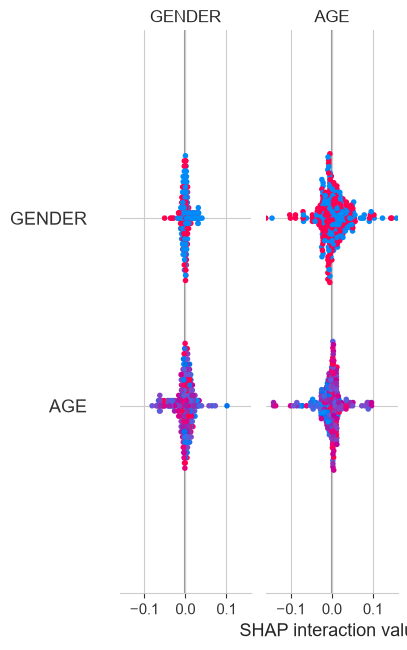

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_scaled if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_bar.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

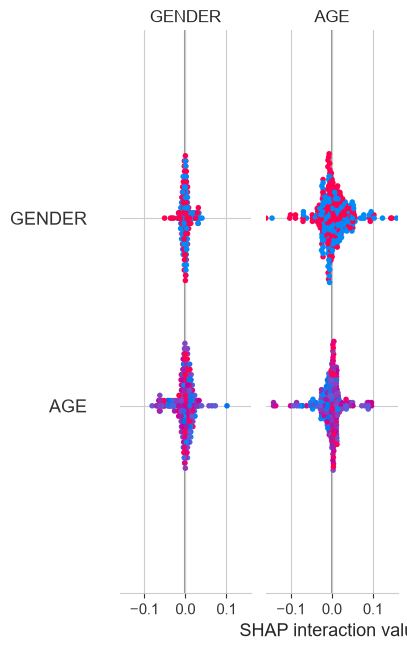

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_scaled if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_beeswarm.png', dpi=150)
plt.show()


In [12]:
def explain_single_prediction(patient_row_scaled, explainer, feature_names, is_tree_model):

    # Get SHAP values
    if is_tree_model:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]  # take first sample

    else:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]

    # Important fix
    sv = np.array(sv).reshape(-1)   # ensures 1D

    # Create dataframe
    impact_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": sv
    })

    impact_df["abs_impact"] = impact_df["shap_value"].abs()

    return impact_df.sort_values("abs_impact", ascending=False)
